<a href="https://colab.research.google.com/github/arifulislam09/ML_Lab_Reporto2/blob/main/ML_Lab_Report02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

**Load Dataset**

In [67]:
df = pd.read_csv('/content/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Input and output

In [68]:
X = df['review']
y = df['sentiment']

print(X.head())
print(y.head())

0    One of the other reviewers has mentioned that ...
1    A wonderful little production. <br /><br />The...
2    I thought this was a wonderful way to spend ti...
3    Basically there's a family where a little boy ...
4    Petter Mattei's "Love in the Time of Money" is...
Name: review, dtype: object
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object


Dataset Info

In [69]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
review       0
sentiment    0
dtype: int64


Sentiment Distribution Visualization

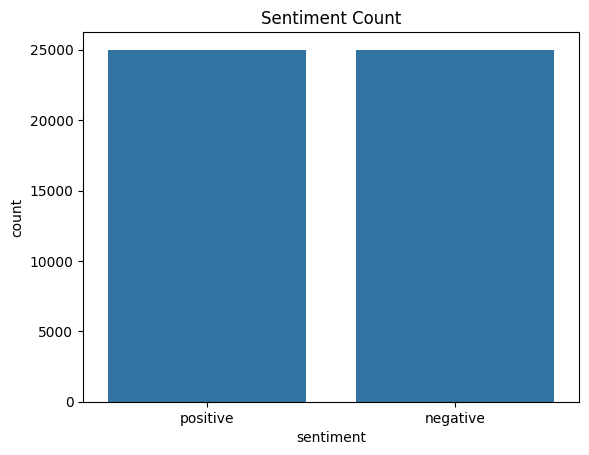

In [70]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Count")
plt.show()

Review Length Visualization

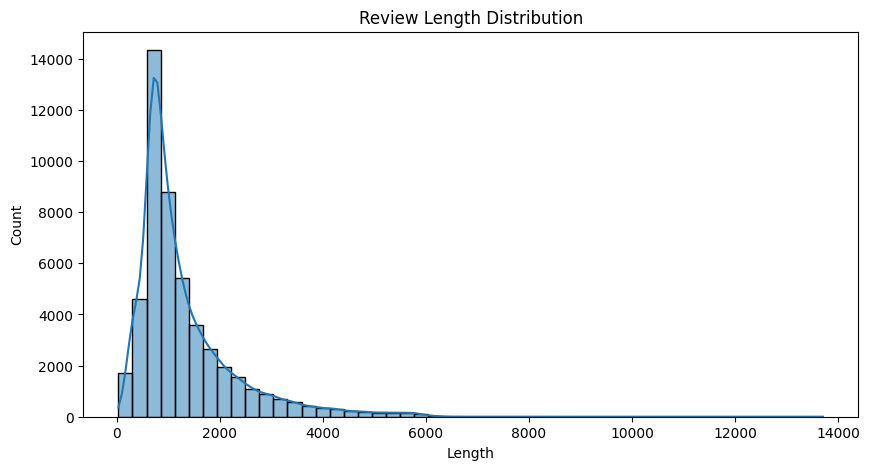

In [71]:
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.show()

Positive Review WordCloud

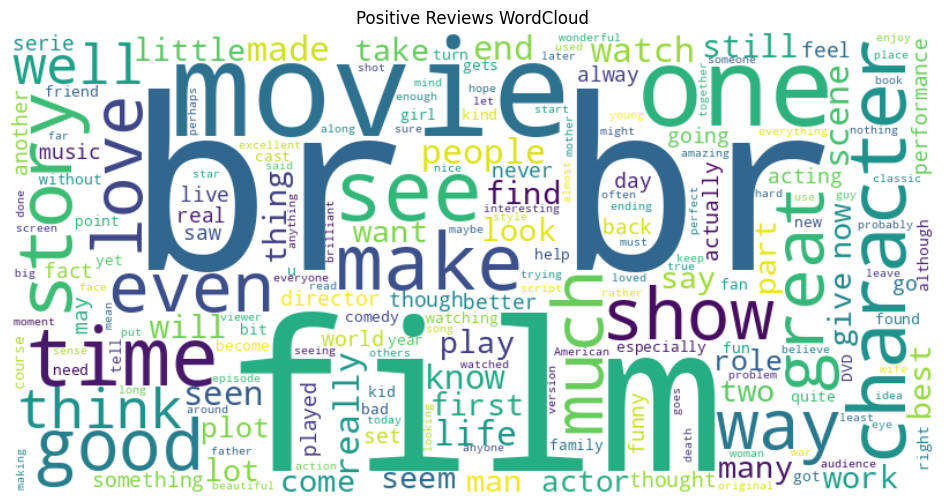

In [72]:

positive_text = " ".join(df[df['sentiment']=='positive']['review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

Negative Review WordCloud

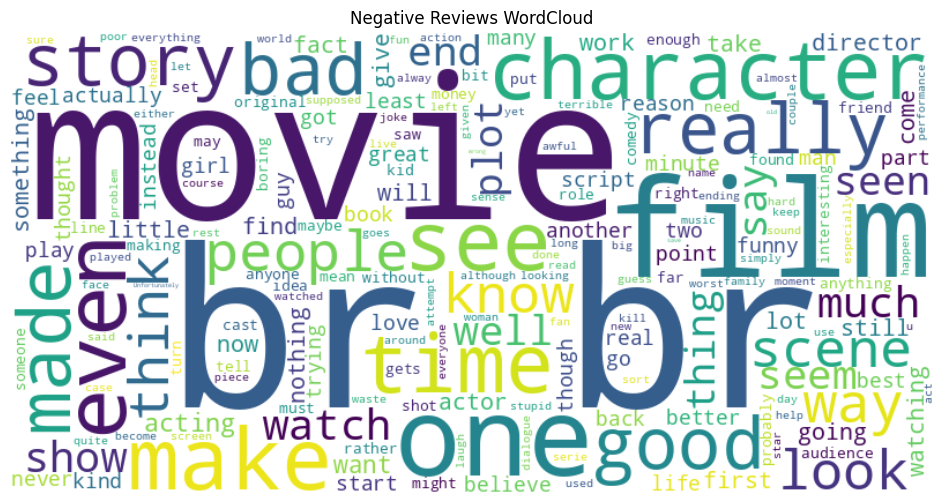

In [73]:
negative_text = " ".join(df[df['sentiment']=='negative']['review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

Text Vectorization

In [74]:
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(X)

print(X.shape)

(50000, 5000)


Most Frequent Words Visualization

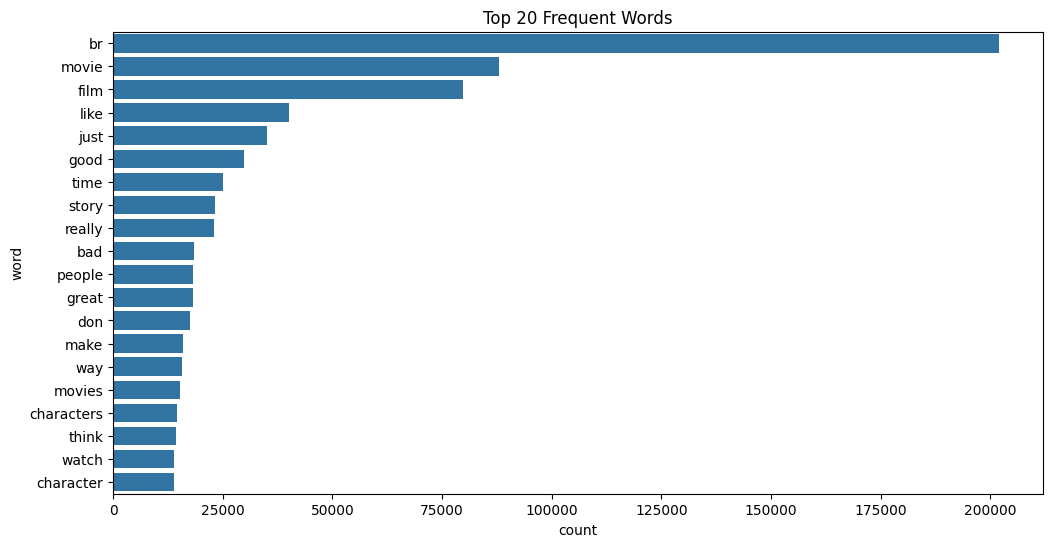

In [75]:
words = vectorizer.get_feature_names_out()
counts = np.array(X.sum(axis=0)).flatten()

freq_df = pd.DataFrame({'word': words, 'count': counts})
top_words = freq_df.sort_values(by='count', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(x='count', y='word', data=top_words)
plt.title("Top 20 Frequent Words")
plt.show()

Train Test Split

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model

In [77]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

# Prediction

In [78]:
y_pred = model.predict(X_test)

# Accuracy

In [79]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8446


# Classification Report

In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.84      0.85      0.84      4961
    positive       0.85      0.84      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



**Confusion Matrix Visualization**

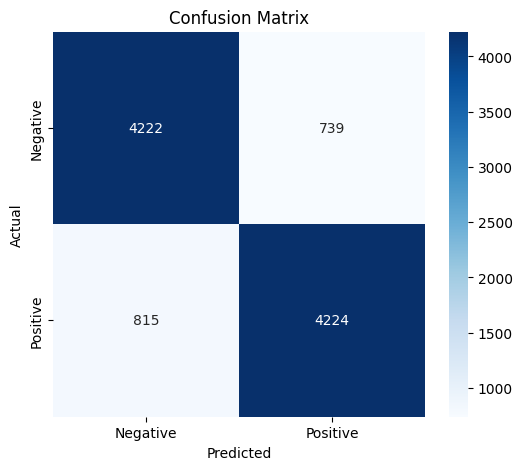

In [81]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()